In [157]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy.interpolate

from geodesics import *
import math
from pathlib import Path
np.random.seed(42)
random.seed(42)

NetworkXError: Node 183 has no position.

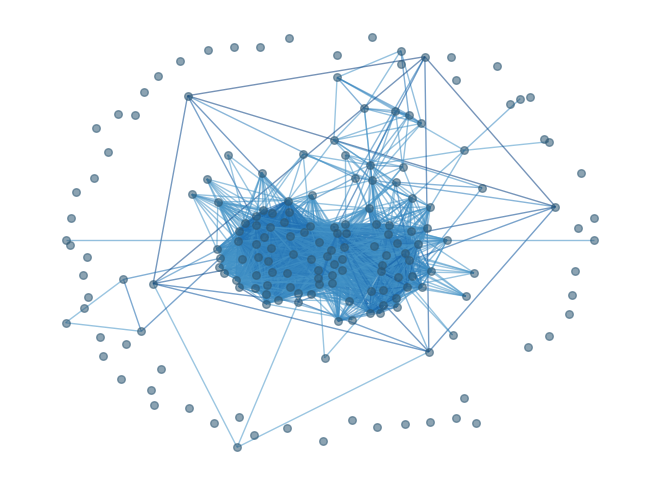

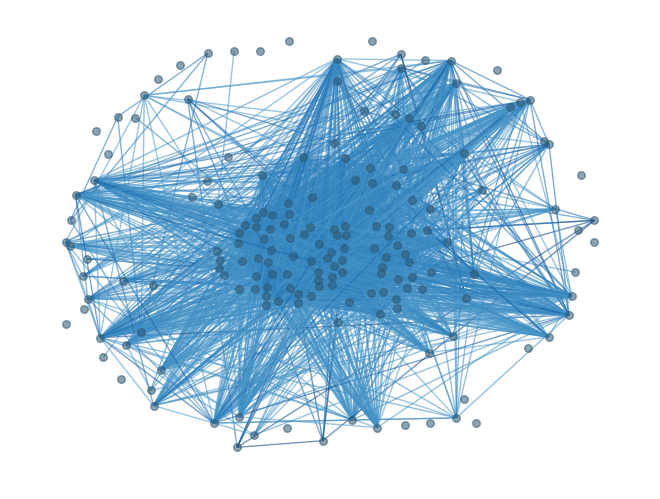

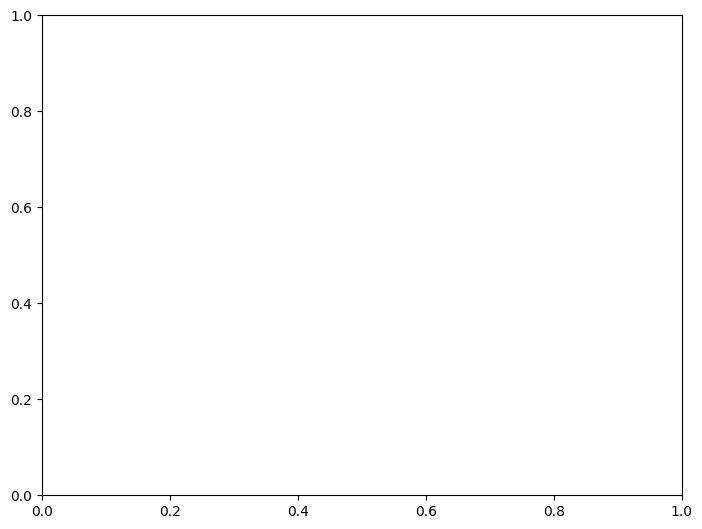

In [160]:
data_subdir = "Bootstrap_Correlation_Matrices/S03"
threshold = 0.2

use_all_data = True
do_transform = False
n_top_entries = 50

current_dir = Path.cwd()
output_dir = current_dir / "Outputs" / data_subdir / f"threshold {threshold}"
output_dir.mkdir(parents=True, exist_ok=True)
graph_dir = output_dir/ "graphs"
graph_dir.mkdir(parents=True, exist_ok=True)
plot_dir = output_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

data_root_path = current_dir.parents[1] / "Data" / data_subdir
filenames = ["corr_E14_16.csv", "corr_E16_18.csv", "corr_L1.csv",  "corr_L2.csv",   "corr_L3.csv"]
data_path = [data_root_path / file for file in filenames]
correlation_pd = [pd.read_csv(corr_file) for corr_file in data_path]
for correlation in correlation_pd:
    correlation.fillna(0, inplace=True)

datas =  [dataframe.iloc[:,1:].values for dataframe in correlation_pd]

indices_temp  = np.zeros(n_top_entries*5,dtype=int)
for i,data in enumerate(datas):
    if not use_all_data:
        np.fill_diagonal(data, 0)
        indices_temp[i*n_top_entries:(i+1)*n_top_entries] = np.argpartition(np.abs(np.max(np.abs(data),axis=1)),-n_top_entries)[-n_top_entries:]
    else:
        np.fill_diagonal(data, 0.5)


if not use_all_data:
    indices = np.unique(indices_temp)
    for i,data in enumerate(datas):
        datas[i] = data[indices][:, indices]

if do_transform:
    for i,data in enumerate(datas):
        datas[i] = 1/2*data+1/2
        np.fill_diagonal(datas[i], 0.5)

# threshold based on absolute value of untransformed data (per sandhu) to build topology.
# weights come for the transformed data I guess

graphs = [nx.from_numpy_array(np.where(abs(data*2-1) > threshold,data,0)) for data in datas]

cmap = plt.cm.Blues
pos = nx.spring_layout(graphs[0],scale=1)

connected_vertices = nx.connected_components(graphs[0])
S = [graphs[0].subgraph(c) for c in connected_vertices]
for subgraph in S:
    if subgraph.order() > 1:
        pos_S = nx.kamada_kawai_layout(subgraph,scale=1)
        pos.update(pos_S)

for i,graph in enumerate(graphs):
    fig = plt.figure()
    edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
    nx.draw(graph, pos, edge_color=weights, width=1, edge_cmap=cmap,edge_vmin = 0,edge_vmax=1,node_size=30,alpha=0.55,node_color="#2e5873"),
    #plt.title(f"Number of Edges: {len(edges)}")
    fig.savefig(graph_dir / f"graph_{i}.pdf",transparent=True)

In [145]:
tvalues = np.linspace(0, 1, num=11)

#geodesics for all pairs
geodesic_pairs = []
for graph1, graph2 in zip(graphs, graphs[1:]):
    geodesic_pairs.append(compute_GW_Geodesics_weighted(graph1,graph2, tvalues,weight_inf_treshold=0, inf_treshold=1e4,threshold_down=0.75, threshold_up=1.25, delete_high_weights=False,
    )[0])

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|2.767211e+07|0.000000e+00|0.000000e+00
    1|5.448052e+05|4.979266e+01|2.712730e+07
    2|7.316769e+04|6.445980e+00|4.716375e+05
    3|6.843128e+04|6.921413e-02|4.736412e+03
    4|6.838391e+04|6.926736e-04|4.736773e+01
    5|6.838344e+04|6.927021e-06|4.736935e-01
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.148556e+07|0.000000e+00|0.000000e+00
    1|2.131759e+07|9.460715e-01|2.016797e+07
    2|2.105961e+07|1.225018e-02|2.579841e+05
    3|2.105702e+07|1.228000e-04|2.585802e+03
    4|2.105700e+07|1.228166e-06|2.586148e+01
It.  |Err         
-------------------
    0|4.471689e+04|
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.798554e-03|0.000000e+00|0.000000e+00
    1|4.820487e-05|9.854499e+01|4.750349e-03
    2|1.312807e-06|3.571894e+01|4.689207e-05
    3|9.196253e-09|1.41

In [146]:
#generate plots of geodesic graphs

# for pair in [0,1,2,3]:
#     for i,graph in enumerate(geodesic_pairs[pair]):
#         fig = plt.figure()
#         edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
#         nx.draw(graph, pos, edge_color=weights, width=1, edge_cmap=cmap,edge_vmin = 0,edge_vmax=1,node_size=30,alpha=0.55,node_color="#2e5873"),
#         fig.savefig(graph_dir / f"graph_{pair}_{i}.pdf",transparent=True)


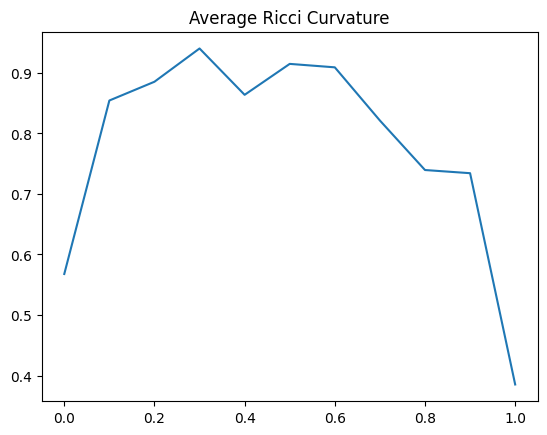

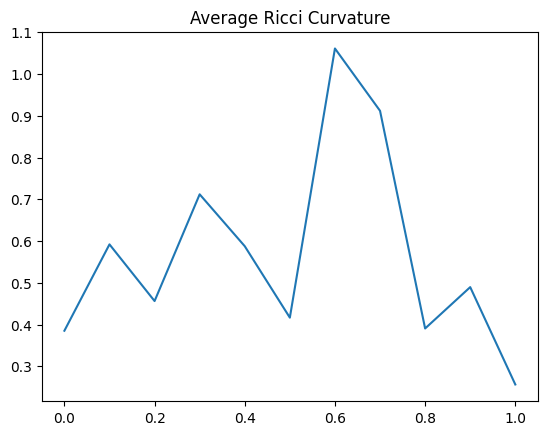

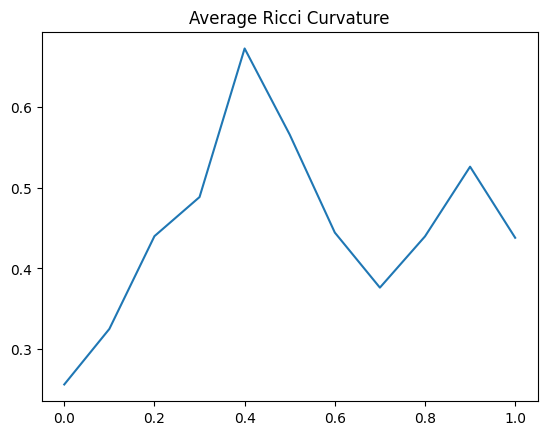

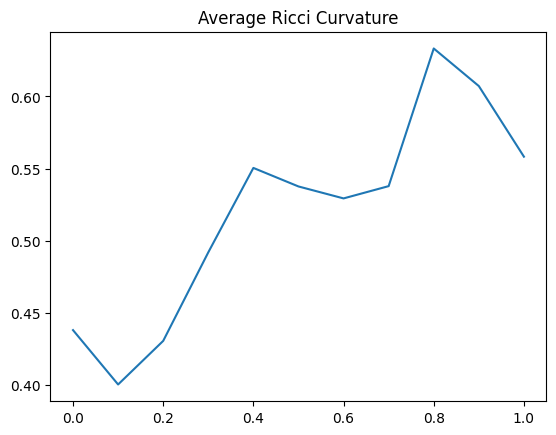

In [147]:
OR_curvatures = []
for i,geodesic_pair in enumerate(geodesic_pairs):
    OR_curvatures.append(compute_curvature_OR(geodesic_pair))
    plot_avg_curvature(tvalues,OR_curvatures[-1])
    plt.savefig(plot_dir / f"g{i}_{i+1}.pdf",transparent=True)


In [148]:
#geodesic for first to final
# t_values_final = np.linspace(0,1,num=40)
# geodesic_final,_ =compute_GW_Geodesics_weighted(graphs[0],graphs[-1], t_values_final,weight_inf_treshold=0.0, inf_treshold=1e4,threshold_down=0.75, threshold_up=1.25, delete_high_weights=False,
#     )

In [149]:
# final_curvatures = compute_curvature_OR(geodesic_final)
# plot_avg_curvature(t_values_final,final_curvatures)
# plt.savefig(plot_dir / f"g0_4.pdf",transparent=True)

In [150]:
# times = [15,17,24,49,49+24]
# total= times[-1] - times[0]
# new_t_values = []
#
# connected_curvature = []
# for i,curvatures in enumerate(OR_curvatures):
#     if i >= 1:
#         new_t_values= np.append(new_t_values,new_t_values[-1]+tvalues[1:]/total*(times[i+1]-times[i]))
#         connected_curvature += curvatures[1:]
#     else:
#         new_t_values= np.append(new_t_values,tvalues/total*(times[i+1]-times[i]))
#         connected_curvature += curvatures
#
# plot_avg_curvature(new_t_values,connected_curvature)
# plt.savefig(plot_dir / f"gstiched.pdf",transparent=True)
#
# realavgs = []
# for kappas in OR_curvatures:
#     realavgs.append(np.average(kappas[0]))
# realavgs.append(np.average(OR_curvatures[-1][-1]))
# plot_avg_curvature(new_t_values,connected_curvature)
# times_normalized =  [(t - times[0]) / total for t in times]
# plt.plot(times_normalized,realavgs,marker="o")
#
# avg = np.zeros(len(final_curvatures))
# for i, kappa in enumerate(final_curvatures):
#     avg[i] = np.average(kappa)
#
# plt.plot(t_values_final,avg)
# plt.legend(["Stiched Geodesic","Linear Interpolant","E14-16 to L3"],loc='center left', bbox_to_anchor=(1.02, 0.5))
# plt.tight_layout()
# plt.savefig(plot_dir / f"gstiched_overlayed.pdf",transparent=True)


It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|2.767211e+07|0.000000e+00|0.000000e+00
    1|5.448052e+05|4.979266e+01|2.712730e+07
    2|7.316769e+04|6.445980e+00|4.716375e+05
    3|6.843128e+04|6.921413e-02|4.736412e+03
    4|6.838391e+04|6.926736e-04|4.736773e+01
    5|6.838344e+04|6.927021e-06|4.736935e-01
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.539208e+07|0.000000e+00|0.000000e+00
    1|2.680847e+07|6.931992e-01|1.858361e+07
    2|2.657767e+07|8.684070e-03|2.308024e+05
    3|2.657523e+07|9.188941e-05|2.441982e+03
    4|2.657515e+07|2.848912e-06|7.571026e+01
It.  |Err         
-------------------
    0|4.471689e+04|
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.798554e-03|0.000000e+00|0.000000e+00
    1|4.820487e-05|9.854499e+01|4.750349e-03
    2|1.312807e-06|3.571894e+01|4.689207e-05
    3|9.196253e-09|1.41

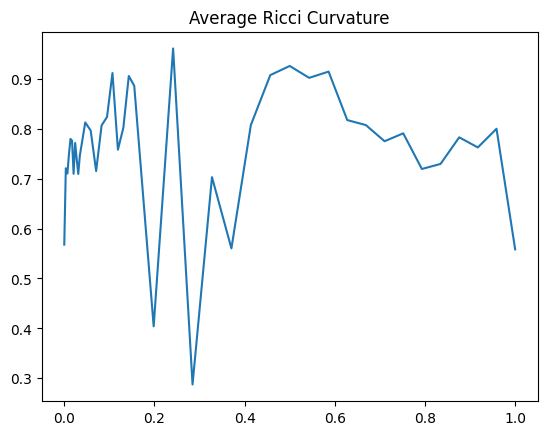

<Figure size 640x480 with 0 Axes>

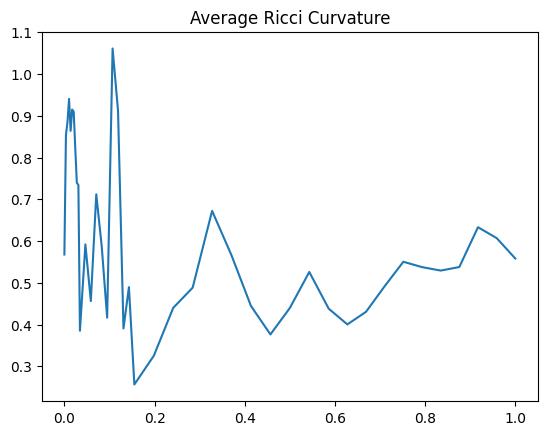

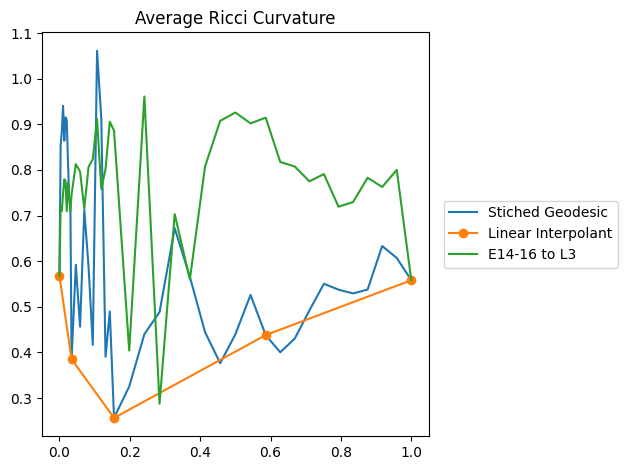

In [151]:
times = [15,17,24,49,49+24]
total= times[-1] - times[0]
new_t_values = []

connected_curvature = []
for i,curvatures in enumerate(OR_curvatures):
    if i >= 1:
        new_t_values= np.append(new_t_values,new_t_values[-1]+tvalues[1:]/total*(times[i+1]-times[i]))
        connected_curvature += curvatures[1:]
    else:
        new_t_values= np.append(new_t_values,tvalues/total*(times[i+1]-times[i]))
        connected_curvature += curvatures

#geodesic for first to final with the same point values as the stitched
geodesic_final_stiched, _ = (compute_GW_Geodesics_weighted(graphs[0], graphs[-1], new_t_values, weight_inf_treshold=0.0, inf_treshold=1e4, threshold_down=0.75, threshold_up=1.25,delete_high_weights=False ))
final_curvatures_stiched = compute_curvature_OR(geodesic_final_stiched)
plot_avg_curvature(new_t_values,final_curvatures_stiched)
plt.savefig(plot_dir / f"g0_4_stiched_points.pdf",transparent=True)

plt.figure()
plot_avg_curvature(new_t_values,connected_curvature)
realavgs = []
for kappas in OR_curvatures:
    realavgs.append(np.average(kappas[0]))
realavgs.append(np.average(OR_curvatures[-1][-1]))
plot_avg_curvature(new_t_values,connected_curvature)
times_normalized =  [(t - times[0]) / total for t in times]
plt.plot(times_normalized,realavgs,marker="o")

avg = np.zeros(len(final_curvatures_stiched))
for i, kappa in enumerate(final_curvatures_stiched):
    avg[i] = np.average(kappa)

plt.plot(new_t_values,avg)
plt.legend(["Stiched Geodesic","Linear Interpolant","E14-16 to L3"],loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig(plot_dir / f"gstiched_overlayed.pdf",transparent=True)


In [152]:
# def relaxed_sign(x,epsilon):
#     if abs(x) < epsilon:
#         return 0
#     else:
#         return np.sign(x)
#
# def relaxed_comparison(x,y):
#     if x == 0 or y == 0:
#         return 1
#     else:
#         return x == y
#
# def compute_relaxed_comparison(xvals,yvals,epsilon):
#     temp = np.zeros(len(xvals))
#     for i,(x,y) in enumerate(zip(xvals,yvals)):
#         temp[i] = relaxed_comparison(relaxed_sign(x,epsilon),relaxed_sign(y,epsilon))
#     return np.average(temp)
#
# times = [15, 17, 24, 49, 49 + 24]
# total = times[-1] - times[0]
# epsilon = 0.1
#
# times_normalized =  [(t - times[0]) / total for t in times]
#
# avg = np.zeros(len(final_curvatures))
# for i, kappa in enumerate(final_curvatures):
#     avg[i] = np.average(kappa)
#
# avg_stiched =  np.zeros(len(connected_curvature))
# for i, kappa in enumerate(connected_curvature):
#     avg_stiched[i] = np.average(kappa)
#
# realavgs = []
# for kappas in OR_curvatures:
#     realavgs.append(np.average(kappas[0]))
# realavgs.append(np.average(OR_curvatures[-1][-1]))
#
# real_spline = scipy.interpolate.make_interp_spline(times_normalized,realavgs,k=1)
# stiched_spline = scipy.interpolate.make_interp_spline(new_t_values,avg_stiched,k=1)
# full_spline = scipy.interpolate.make_interp_spline(t_values_final,avg,k=1)
#
# # old version without using the splines for the piecewise linear interpolant
# # j = 0
# # for i,t_initial in enumerate(times[:-1]):
# #
# #     leftside = (t_initial - times[0]) / total
# #     rightside = (times[i+1] - times[0]) /total
# #     delta_real_sgn = np.sign(realavgs[i+1] - realavgs[i])
# #
# #     interpolant = lambda t: (t- leftside)/(rightside-leftside)*realavgs[i+1] + (t- rightside)/(leftside-rightside)*realavgs[i]
# #     while t_values_final[j] < rightside:
# #         sgn_assignment[j]  = np.sign(avg[j+1] -avg[j]) == delta_real_sgn
# #         delta_real_relaxed[j] = interpolant((t_values_final[j+1]) - interpolant(t_values_final[j])/(t_values_final[j+1]-t_values_final[j]))
# #
# #         delta_real_relaxed_sgn = relaxed_sign(delta_real_relaxed[j], epsilon)
# #
# #         sgn_assignment_relaxed[j] = relaxed_comparison(relaxed_sign((avg[j+1] - avg[j]/(t_values_final[j+1]-t_values_final[j])),epsilon),delta_real_relaxed_sgn)#(relaxed_sign(avg[j+1] - avg[j],epsilon) == delta_real_relaxed_sgn)
# #         j+=1
# #
# # sgn_value = np.average(sgn_assignment)
# # sgn_value_relaxed = np.average(sgn_assignment_relaxed)
# # print(sgn_value,sgn_value_relaxed)
#
# real_eval = real_spline(t_values_final)
# stiched_eval = stiched_spline(t_values_final)
#
# delta_t = t_values_final[1] - t_values_final[0] #assumes uniform grid
# sgn_value = np.average(np.sign(avg[1:] - avg[:-1]) == np.sign(real_eval[1:] - real_eval[:-1]))
# sgn_value_relaxed = compute_relaxed_comparison((avg[1:] - avg[:-1]) /delta_t ,(real_eval[1:] - real_eval[:-1])/delta_t,epsilon)
#
# print(sgn_value,sgn_value_relaxed)
#
# sgn_value_stiched = np.average(np.sign(stiched_eval[1:] - stiched_eval[:-1]) == np.sign(real_eval[1:] - real_eval[:-1]))
# sgn_value_stiched_relaxed = compute_relaxed_comparison((stiched_eval[1:] - stiched_eval[:-1]) /delta_t ,(real_eval[1:] - real_eval[:-1])/delta_t,epsilon)
# print(sgn_value_stiched,sgn_value_stiched_relaxed)
#
# sgn_value_both = np.average(np.sign(stiched_eval[1:] - stiched_eval[:-1]) == np.sign(avg[1:] - avg[:-1]))
# sgn_value_both_relaxed = compute_relaxed_comparison((stiched_eval[1:] - stiched_eval[:-1]) /delta_t ,(avg[1:] - avg[:-1])/delta_t,epsilon)
# print(sgn_value_both,sgn_value_both_relaxed)
#

# Not used for now, but arguably a better way to compute things

# der_real_eval = real_spline.derivative()(t_values_final)
# der_stiched_eval = stiched_spline.derivative()(t_values_final)
# der_full_eval = full_spline.derivative()(t_values_final)
#
# sgn_value2 = np.average(np.sign(der_full_eval) == np.sign(der_real_eval))
# sgn_value2_relaxed = compute_relaxed_comparison(der_full_eval,der_real_eval,epsilon)
# print(sgn_value2,sgn_value2_relaxed)
#
# sgn_value_stiched = np.average(np.sign(der_stiched_eval) == np.sign(der_real_eval))
# sgn_value_stiched_relaxed = compute_relaxed_comparison(der_stiched_eval,der_real_eval,epsilon)
# print(sgn_value_stiched,sgn_value_stiched_relaxed)


In [153]:
#non-uniform code assuming same grid for both the stiched and the full geodesics
def relaxed_sign(x, epsilon):
    if abs(x) < epsilon:
        return 0
    else:
        return np.sign(x)


def relaxed_comparison(x, y):
    if x == 0 or y == 0:
        return 1
    else:
        return x == y


def compute_relaxed_comparison(xvals, yvals, epsilon):
    temp = np.zeros(len(xvals))
    for i, (x, y) in enumerate(zip(xvals, yvals)):
        temp[i] = relaxed_comparison(relaxed_sign(x, epsilon), relaxed_sign(y, epsilon))
    return np.average(temp)


times = [15, 17, 24, 49, 49 + 24]
total = times[-1] - times[0]
epsilon = 0.1

times_normalized = [(t - times[0]) / total for t in times]

avg_final_stiched = np.zeros(len(final_curvatures_stiched))
for i, kappa in enumerate(final_curvatures_stiched):
    avg_final_stiched[i] = np.average(kappa)

avg_stiched = np.zeros(len(connected_curvature))
for i, kappa in enumerate(connected_curvature):
    avg_stiched[i] = np.average(kappa)

realavgs = []
for kappas in OR_curvatures:
    realavgs.append(np.average(kappas[0]))
realavgs.append(np.average(OR_curvatures[-1][-1]))

real_spline = scipy.interpolate.make_interp_spline(times_normalized, realavgs, k=1)
real_eval = real_spline(new_t_values)

delta_t = new_t_values[1:]-new_t_values[:-1]

sgn_value = np.average(np.sign(avg_final_stiched[1:] - avg_final_stiched[:-1]) == np.sign(real_eval[1:] - real_eval[:-1]))

sgn_value_relaxed = compute_relaxed_comparison((avg_final_stiched[1:] - avg_final_stiched[:-1]) /delta_t ,(real_eval[1:] - real_eval[:-1])/delta_t,epsilon)

sgn_value_stiched = np.average(np.sign(avg_stiched[1:] - avg_stiched[:-1]) == np.sign(real_eval[1:] - real_eval[:-1]))
sgn_value_stiched_relaxed = compute_relaxed_comparison((avg_stiched[1:] - avg_stiched[:-1]) /delta_t ,(real_eval[1:] - real_eval[:-1])/delta_t,epsilon)

sgn_value_both = np.average(np.sign(avg_stiched[1:] - avg_stiched[:-1]) == np.sign(avg_final_stiched[1:] - avg_final_stiched[:-1]))
sgn_value_both_relaxed = compute_relaxed_comparison((avg_stiched[1:] - avg_stiched[:-1]) /delta_t ,(avg_final_stiched[1:] - avg_final_stiched[:-1])/delta_t,epsilon)

data = {
    "E14-16 to L3 / Interpolant " : [sgn_value, sgn_value_relaxed],
    "Stitched / Interpolant" : [sgn_value_stiched, sgn_value_stiched_relaxed],
    "E14-16 to L3 / Stitched" : [sgn_value_both,sgn_value_both_relaxed],
}
df = pd.DataFrame(data,index=["Sign Assignment", "Relaxed Sign Assignment"])

latex_code = df.to_latex(caption="Sign Assignment and Relaxed Sign Assignment with $\\epsilon="+str(epsilon)+ "$ for \\cref{subsec: geodesics and curvature}.", label="tab: Sign Assigments",float_format="{:.2f}".format)
print(latex_code)
with open(plot_dir/ "table.tex", "w", encoding="utf-8") as file:
    file.write(latex_code)

\begin{table}
\caption{Sign Assignment and Relaxed Sign Assignment with $\epsilon=0.1$ for \cref{subsec: geodesics and curvature}.}
\label{tab: Sign Assigments}
\begin{tabular}{lrrr}
\toprule
 & E14-16 to L3 / Interpolant  & Stitched / Interpolant & E14-16 to L3 / Stitched \\
\midrule
Sign Assignment & 0.47 & 0.57 & 0.50 \\
Relaxed Sign Assignment & 0.47 & 0.57 & 0.50 \\
\bottomrule
\end{tabular}
\end{table}



In [154]:
ricci_times = np.logspace(-2.0, 1, 7)
dynamic_curvatures = []
for i, geodesic_pair in enumerate(geodesic_pairs):
    dynamic_curvatures.append(compute_curvature_dynamic(geodesic_pair,ricci_times))
    figs = plot_dynamic_curvature(tvalues, ricci_times,dynamic_curvatures[-1])
    for j,fig in enumerate(figs):
        fig.savefig(plot_dir / f"dynamic curvatures g{i}_{i + 1} geotime {tvalues[j]}.pdf", transparent=True)
        plt.close(fig)

  0%|          | 0/7 [00:00<?, ?it/s]Process SpawnPoolWorker-5581:
Process SpawnPoolWorker-5580:
Process SpawnPoolWorker-5579:
Process SpawnPoolWorker-5578:
  0%|          | 0/7 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
dynamic_final_curvatures = compute_curvature_dynamic(geodesic_final_stiched,ricci_times)
# figs = plot_dynamic_curvature(t_values_final, ricci_times,dynamic_final_curvatures)
# for geotime,fig in zip(t_values_final,figs):
#         fig.savefig(main_dir / f"dynamic curvatures g0_4 geotime {geotime}.pdf", transparent=True)
#         plt.close(fig)

In [ ]:
def plot_dynamic_averages(geodesic_time, dynamic_ricii_times, kappa_values):
    avg = np.zeros((len(dynamic_ricii_times),len(geodesic_time)))
    for i, kappa in enumerate(kappa_values):
        avg[:,i] = np.average(kappa,axis=1)

    fig = plt.figure()
    plt.title("Average Dynamic Ricci Curvatures")
    plt.plot(geodesic_time, np.transpose(avg))
    plt.legend([f"$\\tau=\\log_{{10}}({time})$" for time in dynamic_ricii_times], title="Diffusion Parameter",loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()


In [ ]:
#ricci_times_nice = ["-2","-5/3","-4/3","-1","-2/3","-1/3","0","1/3","2/3","1"]
ricci_times_nice = ["-2","-3/2","-1","-1/2","0","1/2","1"]

plot_dynamic_averages(new_t_values,ricci_times_nice,dynamic_final_curvatures)
plt.savefig(plot_dir / f"dynamic g0_4.pdf",transparent=True)

for i,curvature in enumerate(dynamic_curvatures):
    plot_dynamic_averages(tvalues,ricci_times_nice,curvature)
    plt.savefig(plot_dir / f"dynamic g{i}_{i + 1}.pdf", transparent=True)
